<a href="https://colab.research.google.com/github/cosmic-code05/Machine-Learning-Projects/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HOUSE** **PRICE** **PREDICTION**

Objective: Predict the sale price of a house based on its property features using machine learning regression models.

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [3]:
df = pd.read_csv('/content/modified_data[1].csv')

In [4]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


In [6]:
df.shape

(4600, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   object 
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   object 
 15  city            4600 non-null   object 
 16  statezip        4600 non-null   object 
 17  price_per_sqft  4600 non-null   f

In [7]:
df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [8]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261,265.876209
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536,357.503362
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,180.817500
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,243.855000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000,314.840000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,22533.900000


In [11]:
df[df['price']==0]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
4354,2014-05-05,0.0,3.0,1.75,1490,10125,1.0,0,0,4,1490,0,1962,0,3911 S 328th St,Federal Way,WA 98001,0.0
4356,2014-05-05,0.0,4.0,2.75,2600,5390,1.0,0,0,4,1300,1300,1960,2001,2120 31st Ave W,Seattle,WA 98199,0.0
4357,2014-05-05,0.0,6.0,2.75,3200,9200,1.0,0,2,4,1600,1600,1953,1983,12271 Marine View Dr SW,Burien,WA 98146,0.0
4358,2014-05-06,0.0,5.0,3.50,3480,36615,2.0,0,0,4,2490,990,1983,0,21809 SE 38th Pl,Issaquah,WA 98075,0.0
4361,2014-05-07,0.0,5.0,1.50,1500,7112,1.0,0,0,5,760,740,1920,0,14901-14999 12th Ave SW,Burien,WA 98166,0.0
4362,2014-05-07,0.0,4.0,4.00,3680,18804,2.0,0,0,3,3680,0,1990,2009,1223-1237 244th Ave NE,Sammamish,WA 98074,0.0
4374,2014-05-09,0.0,2.0,2.50,2200,188200,1.0,0,3,3,2200,0,2007,0,39612 254th Ave SE,Enumclaw,WA 98022,0.0
4376,2014-05-09,0.0,4.0,2.25,2170,10500,1.0,0,2,4,1270,900,1960,2001,216 SW 183rd St,Normandy Park,WA 98166,0.0
4382,2014-05-12,0.0,5.0,4.50,4630,6324,2.0,0,0,3,3210,1420,2006,0,6925 Oakmont Ave SE,Snoqualmie,WA 98065,0.0
4383,2014-05-13,0.0,5.0,4.00,4430,9000,2.0,0,0,3,4430,0,2013,1923,9235 NE 5th St,Bellevue,WA 98004,0.0


In [12]:
df[df['price']>5000000][['price','bedrooms','bathrooms','sqft_living','sqft_lot']]

,price,bedrooms,bathrooms,sqft_living,sqft_lot
2286,7062500.0,5.0,4.5,10040,37325
4346,12899000.0,3.0,2.5,2190,11394
4350,26590000.0,3.0,2.0,1180,7793


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df[df['price']==0].shape

(49, 18)

In [15]:
df = df[df['price'] > 0]
df = df.drop(columns=['price_per_sqft'])

In [16]:
df.shape

(4551, 17)

**EDA**

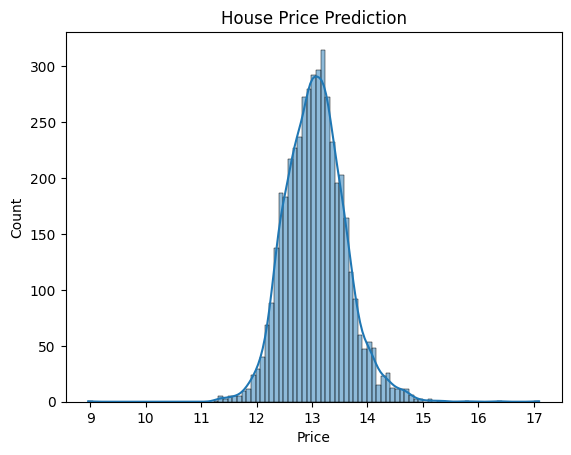

In [22]:
sns.histplot(np.log1p(df['price']), kde=True)
plt.title('House Price Prediction')
plt.xlabel('Price')
plt.show()

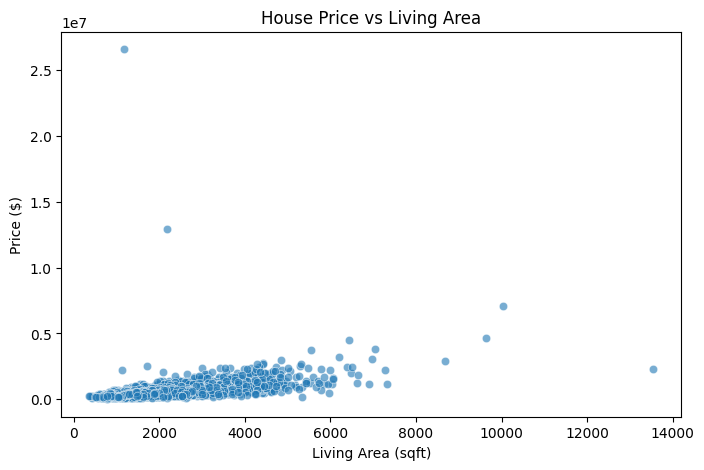

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data = df,
    x = 'sqft_living',
    y = 'price',
    alpha = 0.6
)

plt.title('House Price vs Living Area')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price ($)')
plt.show()

<Axes: >

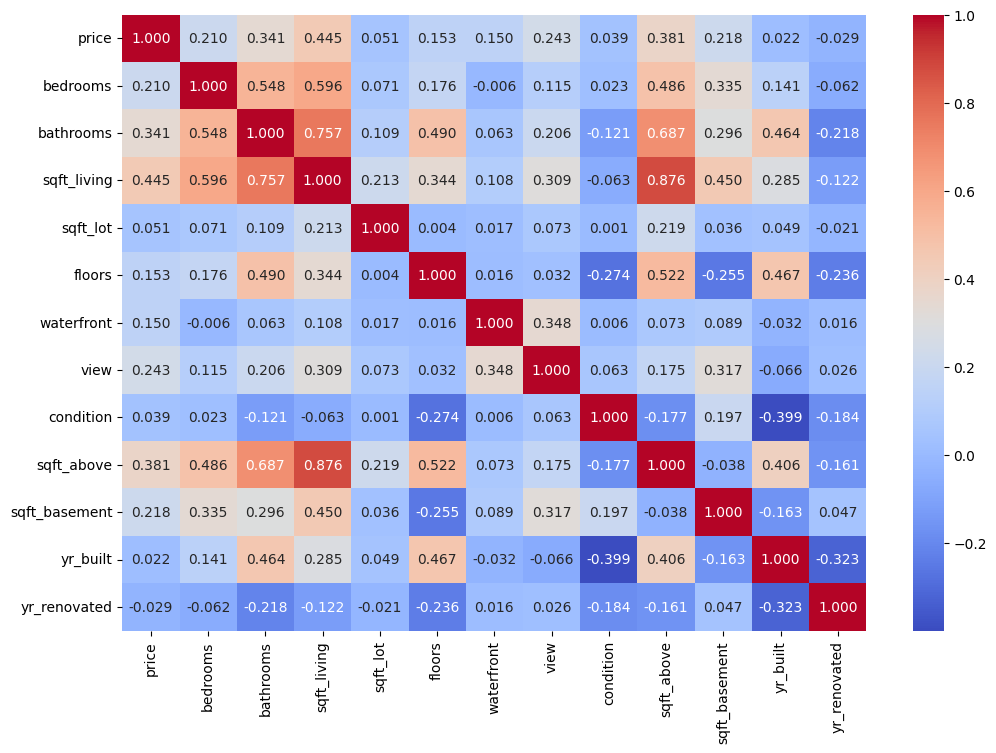

In [37]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot = True,
    cmap = 'coolwarm',
    fmt = '.3f'
)

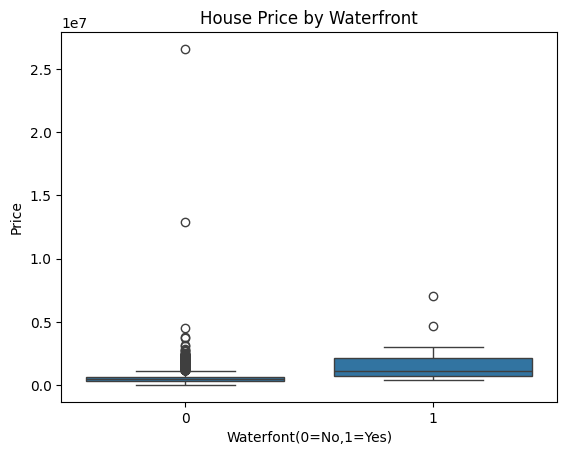

In [40]:
sns.boxplot(data=df, x='waterfront', y='price')
plt.title('House Price by Waterfront')
plt.xlabel('Waterfont(0=No,1=Yes)')
plt.ylabel('Price')
plt.show()

In [42]:
x = df.drop(columns=['price','street','city','statezip'])
y = df['price']

In [43]:
x.shape, y.shape

((4551, 13), (4551,))

**Splitting the data into Training and Testing Sets**

In [55]:
X = df.drop(columns=['price', 'street', 'city', 'statezip'])
y = df['price']

x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [46]:
x_train.shape, x_test.shape

((3640, 13), (911, 13))

**Train** **the** **Model**

In [57]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [60]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

MAE: $162,204.93
RMSE: $244,793.23
R² Score: 0.5972


In [62]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = LinearRegression()
model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)

In [64]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)

In [65]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"MAE: ${rf_mae:,.2f}")
print(f"RMSE: ${rf_rmse:,.2f}")
print(f"R² Score: {rf_r2:.4f}")

MAE: $162,750.48
RMSE: $267,526.72
R² Score: 0.5189


In [67]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(x_train, y_train)

xgb_pred = xgb_model.predict(x_test)

In [68]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"MAE: ${xgb_mae:,.2f}")
print(f"RMSE: ${xgb_rmse:,.2f}")
print(f"R² Score: {xgb_r2:.4f}")

MAE: $160,467.67
RMSE: $280,773.21
R² Score: 0.4701


Feature Coefficients

In [69]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(coef_df)

          Feature    Coefficient
2     sqft_living  123955.261066
8      sqft_above  117147.587794
1       bathrooms   56644.152117
6            view   41483.844014
9   sqft_basement   37223.743691
5      waterfront   31224.593738
7       condition   27922.100546
13          month   17758.625450
4          floors   13927.845327
11   yr_renovated    5500.510831
12           year       0.000000
3        sqft_lot  -22956.049753
0        bedrooms  -54556.284696
10       yr_built  -74833.368163


Actual vs Predicted

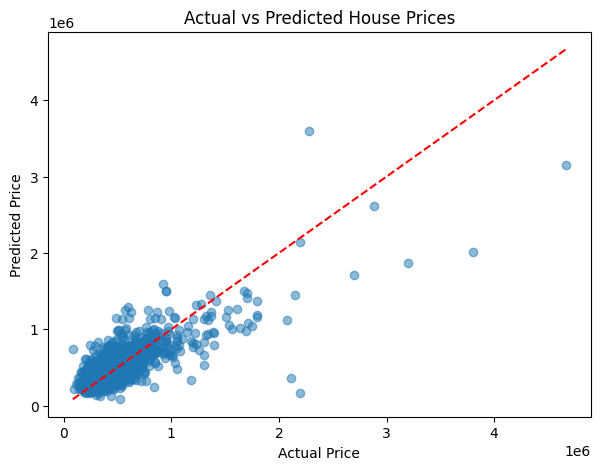

In [70]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')

plt.show()

Residual Analysis

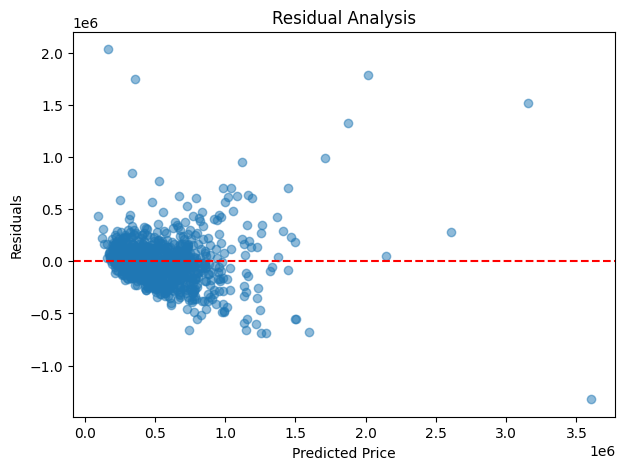

In [71]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Analysis')

plt.show()

In [72]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [mae, rf_mae, xgb_mae],
    'RMSE': [rmse, rf_rmse, xgb_rmse],
    'R2 Score': [r2, rf_r2, xgb_r2]
})

print(results)

               Model            MAE           RMSE  R2 Score
0  Linear Regression  162204.928014  244793.229639  0.597207
1      Random Forest  162750.483889  267526.724865  0.518919
2            XGBoost  160467.671885  280773.213978  0.470099


In [74]:
joblib.dump(model, 'house_price_model.pkl')
joblib.dump(scaler, 'house_price_scaler.pkl')

print("✓ Model and scaler saved successfully!")

✓ Model and scaler saved successfully!


In [76]:
print("=" * 60)
print("HOUSE PRICE PREDICTION - FINAL RESULTS")
print("=" * 60)

print(f"Dataset Size: {len(df)} rows")
print(f"Number of Features: {X.shape[1]}")
print(f"Best Model: Linear Regression")
print(f"R² Score: {r2:.4f}")
print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")

print("\n✓ Completed successfully!")

HOUSE PRICE PREDICTION - FINAL RESULTS
Dataset Size: 4551 rows
Number of Features: 14
Best Model: Linear Regression
R² Score: 0.5972
MAE: $162,204.93
RMSE: $244,793.23

✓ Completed successfully!
